In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [2]:
from astropy import units as un, constants as cons
import numpy as np
import cooling_flow as CF
import HaloPotential as Halo
import matplotlib.pyplot as plt
import GrackleCooling as Cool
import AgoraPotential as Agora

In [3]:
plt.rcParams['font.size']=22
plt.rcParams['axes.linewidth']=2
plt.rcParams['xtick.major.size']=10
plt.rcParams['xtick.minor.size']=5
plt.rcParams['xtick.major.width']=2
plt.rcParams['xtick.minor.width']=1
plt.rcParams['xtick.direction']='in'
plt.rcParams['ytick.major.size']=10
plt.rcParams['ytick.minor.size']=5
plt.rcParams['ytick.major.width']=2
plt.rcParams['ytick.minor.width']=1
plt.rcParams['ytick.direction']='in'

In [4]:
Msun = 1.988409870698051e+33
G = 6.674299999999999e-08
mp = 1.67262192369e-24
kpc = 3.0856775814913673e+21
gamma = 5./3.
yr_to_sec = 3.154e+7
Myr = yr_to_sec * 1.e6
kmps = 1.e5
kb = 1.38e-16


In [5]:
Mvir=1.074e12*cons.M_sun #MW mass agora
potential = Agora.NFW(Mvir=1.074e12*cons.M_sun, z=0, cvir=10)

FileNotFoundError: /Users/aditivijayan/Projects/M82_setup/HaloProfile/vcirc_agora.txt not found.

In [14]:

Z2Zsun = 1.
z = 0.
cooling = Cool.GrackleCooling(Z2Zsun,z)

In [15]:
max_step = 0.1                         #lowest resolution of solution in ln(r)
R_min    = 0.01*un.kpc                  #inner radius of supersonic part of solution
R_max    = potential.rvir()    #outer radius of integration
R_sonics  = np.array([0.65])*un.kpc  #sonic radii

In [52]:
transsonic_solutions = []
for R_sonic in R_sonics:
    print('R_sonic = %s'%R_sonic)
    transsonic_solutions.append(CF.shoot_from_sonic_point(potential,
                                                    cooling,
                                                    R_sonic,
                                                    R_max,
                                                    R_min,
                                                    max_step=max_step,
                                                    calcInwardSolution=False,
                                                    pr=True))
                        

R_sonic = 0.65 kpc
Integrated with v_c^2/c_s^2 (R_sonic) =1.000010;  no transsonic solutions
Integrated with v_c^2/c_s^2 (R_sonic) =0.500015;  maximum r=3 kpc; stop reason: unbound
Integrated with v_c^2/c_s^2 (R_sonic) =0.750012;  maximum r=10 kpc; stop reason: sonic point
Integrated with v_c^2/c_s^2 (R_sonic) =0.625014;  maximum r=23 kpc; stop reason: unbound
Integrated with v_c^2/c_s^2 (R_sonic) =0.687513;  maximum r=35 kpc; stop reason: sonic point
Integrated with v_c^2/c_s^2 (R_sonic) =0.656263;  maximum r=54 kpc; stop reason: unbound
Integrated with v_c^2/c_s^2 (R_sonic) =0.671888;  maximum r=105 kpc; stop reason: sonic point
Integrated with v_c^2/c_s^2 (R_sonic) =0.664076;  maximum r=86 kpc; stop reason: unbound
Integrated with v_c^2/c_s^2 (R_sonic) =0.667982;  maximum r=144 kpc; stop reason: unbound
Integrated with v_c^2/c_s^2 (R_sonic) =0.669935;  maximum r=200 kpc; stop reason: sonic point
Integrated with v_c^2/c_s^2 (R_sonic) =0.668959;  maximum r=190 kpc; stop reason: unboun

/Users/aditivijayan/Projects/M82_setup/HaloProfile/AgoraIC/cooling_flow_stern-19/cooling_flow.py:65: RuntimeWarning: overflow encountered in scalar power
  rho,T=e**ln_rho*un.g/un.cm**3, e**ln_T*un.K
/Users/aditivijayan/miniforge3/lib/python3.12/site-packages/astropy/units/quantity.py:659: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/aditivijayan/miniforge3/lib/python3.12/site-packages/astropy/units/quantity.py:659: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/aditivijayan/Projects/M82_setup/HaloProfile/AgoraIC/cooling_flow_stern-19/AgoraIC_for_Quokka/GrackleCooling.py:97: RuntimeWarning: divide by zero encountered in log10
  return self.f_Cooling((log(T.to('K').value), log(nH.to('cm**-3').value))) * un.erg*un.cm**3/un.s
/Users/aditivijayan/miniforge3/lib/python3.12/site-packages/astropy/units/quantity.py:659: Runti

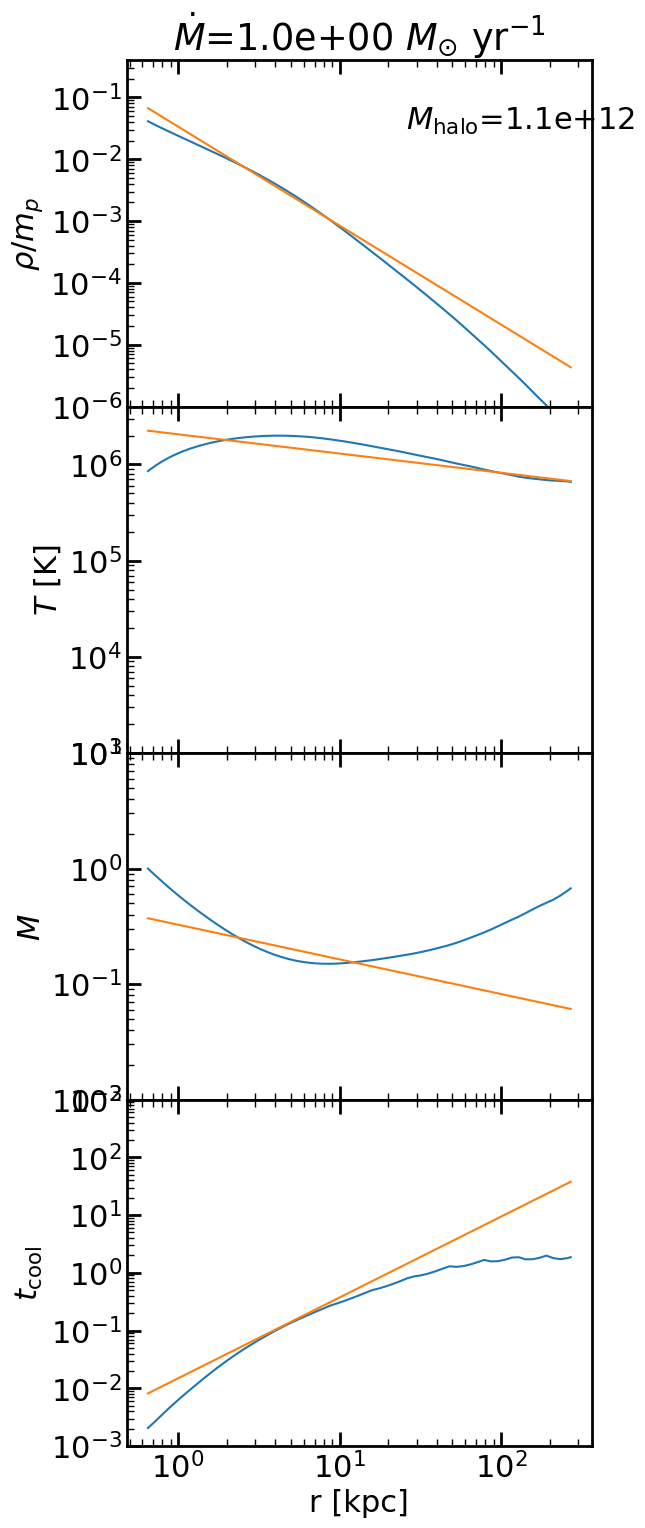

In [53]:
res = transsonic_solutions[0]
fs  = 0
idx = 0 
X=0.75
Mhalo=1.074e12*Msun
mu = 0.6


r = res.Rs()
rkpc = r.value
B = res.Bernoulli().value
rho = res.rhos().value
cs = res.cs().value
Mdot = res.Mdot.value * Msun/yr_to_sec
tcool = res.t_cools().value 
lambda_cool = res.Lambdas().value
v = res.vs().value
T = cs * cs * mu * mp * kmps * kmps/gamma/kb
gamma = 5./3.
v = Mdot/(4*np.pi*(rkpc*kpc)**2 * rho)
Mach = v/cs/kmps

lambda_cool = 0.6e-22
Mach_anl = 0.11 * (Mhalo/(1.e12*Msun))**(-0.72) * (Mdot/(Msun/yr_to_sec))**(0.5) * (lambda_cool/1.e-22)**(0.5) * (r/100)**(-0.3) 
nH_anl   = 1.6e-5 * (Mhalo/(1.e12*Msun))**(0.36) * (lambda_cool/1.e-22)**(-0.5) * (r/100)**(-1.6)
tcool_anl = 7.2 * (Mhalo/(1.e12*Msun))**(0.36) * (Mdot/(Msun/yr_to_sec))**(-0.5) * (lambda_cool/1.e-22)**(-0.5) * (r/100)**(1.4) 
T_anl = X * mu * tcool_anl * (gamma-1) * nH_anl * lambda_cool * 1.e9 * yr_to_sec/kb 
Rsonic = 0.06 * (Mhalo/(1.e12*Msun))**(-2.4) * (Mdot/(Msun/yr_to_sec))**(1.67) * (lambda_cool/1.e-22)**(0.36) * kpc
Rhalf = 3.0*(Mhalo/1e12/Msun)**(1/3)*kpc


fig, ax = plt.subplots(4, 1, gridspec_kw = {'wspace':0.1, 'hspace':0.0},figsize=(6, 18))

ylabel = [r'$\rho/m_p$', r'$T$ [K]', r'$M$', r'$t_{\rm cool}$']

ax[0].plot(rkpc, rho*X/mp)
ax[0].plot(rkpc, nH_anl)
ax[1].plot(rkpc, T)
ax[1].plot(rkpc, T_anl)
ax[2].plot(rkpc, Mach)
ax[2].plot(rkpc, Mach_anl)
ax[3].plot(rkpc, tcool)
ax[3].plot(rkpc, tcool_anl)


ax[-1].set_xlabel('r [kpc]')
for i in range(4):
    ax[i].set_ylabel(ylabel[i])
plt.setp(ax, 'xscale', ('log'))
plt.setp(ax, 'yscale', ('log'))
# plt.setp(ax, 'xlim', (0.5,2.))
ax[0].set_ylim(1.e-6, 4.e-1)
ax[1].set_ylim(1.e3, 4.e6)
ax[2].set_ylim(1.e-2,1.e1)
ax[3].set_ylim(1.e-3,1.e3)

ax[0].tick_params(axis='x', which='both', labelbottom=False, top=True, bottom=True)
ax[1].tick_params(axis='x', which='both', labelbottom=False, top=True, bottom=True)
ax[-2].tick_params(axis='x', which='both', top=True, bottom=True, labelbottom=False)
ax[-1].tick_params(axis='x', which='both', top=True, bottom=True, labelbottom=True)
ax[0].set_title(r'$\dot{M}$=%.1e'%(Mdot*yr_to_sec/Msun) + r' $M_{\odot} \ \rm{yr}^{-1}$')
ax[0].text(0.6, 0.8, r'$M_{\rm halo}$=%.1e'%(Mhalo/Msun), transform=ax[0].transAxes)
# ax[0].text(0.6, 0.7, r'$M_{\rm gas}$=%.1e'%(tot_gas_mass/Msun), transform=ax[0].transAxes)
# ax[0].text(0.6, 0.7, r'$\rho_{\rm ini}$=%.1e'%(rho0/mp), transform=ax[0].transAxes)
# ax[0].text(0.6, 0.6, r'$T_{\rm ini}$=%.1e'%(T), transform=ax[0].transAxes)

image_name = 'Figures/solution_' + str(Mdot*yr_to_sec/Msun) +'.jpeg'
# plt.savefig(image_name, bbox_inches='tight')

In [16]:
filename ='agora_halo_IC.dat'

r = res.Rs().value
rho = res.rhos().value
cs = res.cs().value 
v = res.vs().value 
vc = np.sqrt(res.vc2().value)
T = cs * cs * mu * mp * kmps * kmps/gamma/kb
eint = (cs*kmps)**2 * rho/gamma/(gamma-1)
ekin = 0.5 * rho * (v*kmps)**2
etot = eint + ekin
rsonic = R_sonics[0].value
mom_r = rho * v

header = ("r[kpc] vc[km/s] rho v T"  f"Mdot[Msun/yr] = {Mdot*yr_to_sec/Msun:.6e} " f"rsonic[kpc] = {rsonic:.6e} "  f"Z2Zsun = {Z2Zsun:.2e} ")

data = np.column_stack([r, vc, rho, v, T ])
np.savetxt(filename, data, header=header, fmt="%.6e")

Norm= 0.024359529100200113


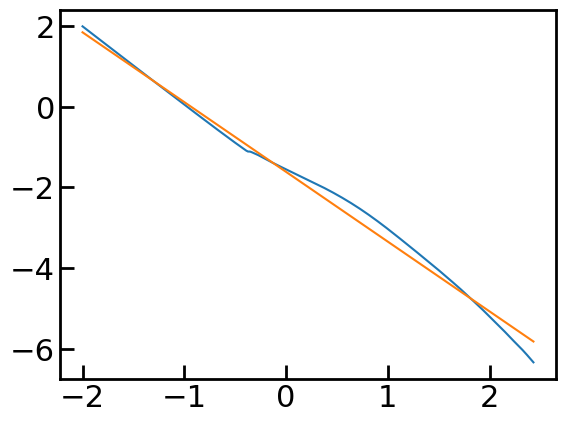

In [48]:
#Calculate normalisation of n_e

cloudy_H_mass_fraction = 1. / (1. + 0.1 * 3.971)
X = cloudy_H_mass_fraction
Z = 0.02  # metal fraction by mass
Y = 1. - X - Z
rhoH = rho * X
rho = rhoH / cloudy_H_mass_fraction
mean_metals_A = 16.
electron_mass_cgs = 9.1093897e-28
m_H = 1.672623e-24
mu = 0.6 
n_e = (rho / m_H) * (1.0 - mu * (X + Y / 4. + Z / mean_metals_A)) / \
                 (mu - ( electron_mass_cgs / m_H))
        

x = np.log10(r.value)
y = np.log10(n_e)
m,c = np.polyfit(x,y, deg=1)
yfit = m*x + c
plt.plot(x,y)
plt.plot(x,yfit)
print('Norm=', 10**c)